# Vanilla Agentic Search

This notebook walks you through a vanilla agentic search example with a search tool to run semantic search queries over a database.

![](../img/agent_search_for_context_engineering_overview.png)

## Preparation

Make sure you have completed the setup instructions according to the README.md.

Load environment variables from `.env` file, such as API keys.

In [ ]:
import os                                                                                                                                                                                                          
from dotenv import load_dotenv

load_dotenv()

LITELLM_API_KEY=os.getenv("LITELLM_API_KEY")
LITELLM_API_BASE=os.getenv("LITELLM_API_BASE")

ES_URL=os.getenv("ELASTICSEARCH_URL")
ES_USERNAME=os.getenv("ELASTICSEARCH_USERNAME")
ES_PASSWORD=os.getenv("ELASTICSEARCH_PASSWORD")

JINA_API_KEY=os.getenv("JINA_API_KEY")

## Set up basic agent with a vector search tool

Follows the [basic Quickstart](https://docs.langchain.com/oss/python/langchain/quickstart)

### Configure the LLM

Set up your LLM with the right parameters for your use case:
Below, we're using OpenAI's models through LiteLLM but you can switch it out with any model capable of tool use.

In [17]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    openai_api_base=LITELLM_API_BASE,
    api_key=LITELLM_API_KEY,
    model="llm-gateway/gpt-5.4-nano",
    temperature=0.5,
)


### Define the system prompt

The system prompt defines your agent’s role and behavior. 

We also include information about what out-of-context knowledge source it has. In this case it has access to an **Elasticsearch index** with the conference data.

In [19]:
SYSTEM_PROMPT = open("01_system_prompt_vanilla_agentic_search.md", 'r').read()

print(SYSTEM_PROMPT)

You are a search agent tasked with answering questions about the AI Engineer Europe 2026 Conference.

You have access to different context retrieval tools to help you answer user queries.

Before answering a question decide whether or not you need to retrieve additional context to answer the question correctly.
If the retrieved context does not contain relevant information to answer the query, say that you don't know. 

## Elasticsearch (`conference_schedule`)

The conference sessions are indexed in Elasticsearch. One document per session.

Basic Auth: ELASTICSEARCH_URL + ELASTICSEARCH_USERNAME + ELASTICSEARCH_PASSWORD

| Field | Description |
|--------------|------------|
| `text` | The string that was embedded: each session’s title plus description (blank line between them). It does not include day, time, room, or speakers. |
| `vector` | Dense embedding of `text`, used for similarity search. |
| `metadata` | Structured fields (see metadata description below) |


| Field | Descriptio

### Create semantic search tool

Tools let a model interact with external systems by calling functions you define. Tools can depend on runtime context and also interact with agent memory.
Notice below how the get_user_location tool uses runtime context:


[Create a retriever tool](https://docs.langchain.com/oss/python/langgraph/agentic-rag)

#### Setup embedding model and vector store

[Jina Embeddings](https://docs.langchain.com/oss/python/integrations/embeddings/jina)

In [8]:
from langchain_community.embeddings import JinaEmbeddings
from langchain_elasticsearch import ElasticsearchStore

# Set up the embedding model
embeddings = JinaEmbeddings(
    jina_api_key=JINA_API_KEY, 
    model_name="jina-embeddings-v5-text-small"
)

# Set up the vector store
vector_store = ElasticsearchStore(
    es_url=ES_URL,
    es_user=ES_USERNAME,
    es_password=ES_PASSWORD,
    index_name="conference_schedule",
    embedding=embeddings,
)

#### Set up the retriever

In [9]:
# Set up the retriever
retriever = vector_store.as_retriever(
    search_type="similarity_score_threshold", 
    search_kwargs={"score_threshold": 0.2}
)

retriever.invoke("Talks about context engineering.")

[Document(metadata={'title': 'Connecting the Dots with Context Graphs', 'day': 'April 9', 'time': '2:30-2:50pm', 'room': 'St. James', 'type': 'talk', 'track': 'Context Engineering', 'speakers': 'Stephen Chin'}, page_content='Connecting the Dots with Context Graphs\n\nAI systems need more than intelligence; they need context that persists. Without it, even strong models can misinterpret information, lose decision rationale, or repeat the same mistakes. Context Graphs have emerged as a practical pattern for agentic AI: a living graph that captures not only what was retrieved or known, but how context led to actions through tool calls, constraints, policies, and outcomes, stitched across entities and time so precedent becomes searchable.\n\nThis talk explores context engineering as the discipline of designing that context layer, and shows how context graphs complement retrieval by enabling multi-hop, structured context assembly (building on GraphRAG-style hierarchical summaries) while imp

#### Create a retriever tool using the [`@tool` decorator](https://reference.langchain.com/python/langchain-core/tools/convert/tool):

The `@tool` decorator converts Python functions into tools. By default the function name becomes the **tool name** and the docstring becomes the **tool description**.

**Best practices for tool descriptions:**
- Core purpose: A high-level summary of what the tool does
- Trigger: When the tool should be used (and when it should not).
- Action: Which specific data the tool retrieves or modifies, and what type of questions it can answer.
- Limitations: What important limitations and constraints exist, such as specific query languages or formats.
- Relationships with other tools: Does one tool affect another tool, or are there any preconditions?
- Examples: Specific few-shot examples of user queries and how to use the tool for them, such as how to determine the optimal search strategy or when to use which operator.

In [10]:
from langchain.tools import tool

@tool()
def find_conference_sessions(query: str) -> str:
    """Search and return information about the sessions at the AI Engineer Europe 2026 conference.

    Args:
        query: The query to search for.

    Returns:
        A string containing the information about the sessions.
    """
    docs = retriever.invoke(query)
    return "\n\n".join([f"{doc.metadata['type']} by {doc.metadata['speakers']}: {doc.metadata['title']}\nDescription:{doc.page_content}" for doc in docs])

retriever_tool = find_conference_sessions

# Test retriever tool
print(retriever_tool.invoke({"query": "Talks about context engineering."}))

talk by Stephen Chin: Connecting the Dots with Context Graphs
Description:Connecting the Dots with Context Graphs

AI systems need more than intelligence; they need context that persists. Without it, even strong models can misinterpret information, lose decision rationale, or repeat the same mistakes. Context Graphs have emerged as a practical pattern for agentic AI: a living graph that captures not only what was retrieved or known, but how context led to actions through tool calls, constraints, policies, and outcomes, stitched across entities and time so precedent becomes searchable.

This talk explores context engineering as the discipline of designing that context layer, and shows how context graphs complement retrieval by enabling multi-hop, structured context assembly (building on GraphRAG-style hierarchical summaries) while improving explainability and evaluation. Attendees will leave with a practical understanding of how to build context pipelines that combine contextual retriev

### Create the agent

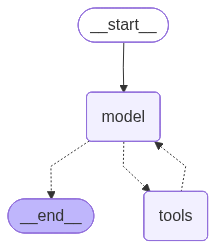

In [11]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    system_prompt=SYSTEM_PROMPT,
    tools=[retriever_tool],
)

agent

## Run the agent

### Agent uses tool to retrieve context

In [12]:
# Run the agent
input_message = {
    "role": "user",
    "content": (
        "Which sessions are about context engineering?"
    ),
}

# Stream
for step in agent.stream(
    {"messages": [input_message]},
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which sessions are about context engineering?
================================== Ai Message ==================================
Tool Calls:
  find_conference_sessions (call_ttX9BqMsnz1FhmXSNxWeahTa)
 Call ID: call_ttX9BqMsnz1FhmXSNxWeahTa
  Args:
    query: context engineering
================================= Tool Message =================================
Name: find_conference_sessions

track_keynote by Ryan Lopopolo: Harness Engineering AMA
Description:Harness Engineering AMA

talk by Stephen Chin: Connecting the Dots with Context Graphs
Description:Connecting the Dots with Context Graphs

AI systems need more than intelligence; they need context that persists. Without it, even strong models can misinterpret information, lose decision rationale, or repeat the same mistakes. Context Graphs have emerged as a practical pattern for agentic AI: a living graph that captures not only what was retrieved or known

### Agent doesn't use tool to retrieve context

In [18]:
# Run the agent
input_message = {
    "role": "user",
    "content": (
        "Hello, I'm so excited to be at the AI Engineer Europe 2026 conference!"
    ),
}

# Stream
for step in agent.stream(
    {"messages": [input_message]},
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello, I'm so excited to be at the AI Engineer Europe 2026 conference!
================================== Ai Message ==================================

That’s great to hear—welcome! 🎉

What would you like to find out about the AI Engineer Europe 2026 conference? For example:
- the schedule for a specific day/time
- sessions about a particular topic (e.g., RAG, agents, evaluation, MLOps, LLM infra)
- keynotes/workshops by a certain speaker
- where/when a session is taking place


### Failure mode

In [16]:
# Run the agent
input_message = {
    "role": "user",
    "content": (
        "What is Leonie's session about?"
    ),
}

# Stream
for step in agent.stream(
    {"messages": [input_message]},
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Leonie's session about?
================================== Ai Message ==================================
Tool Calls:
  find_conference_sessions (call_OcFQw5da8nJ1HWnLWrQFw8W9)
 Call ID: call_OcFQw5da8nJ1HWnLWrQFw8W9
  Args:
    query: Leonie session about
================================= Tool Message =================================
Name: find_conference_sessions

workshop by Matt Pocock: (untitled session)
Description:(untitled session)

workshop by Misha Kaletsky, Jonas Templestein: (untitled session)
Description:(untitled session)

workshop by Eric Zakariasson: (untitled session)
Description:(untitled session)

workshop by Michael Arnaldi: (untitled session)
Description:(untitled session)
================================== Ai Message ==================================

I don’t know from the conference schedule data I can access: the search results I’m getting don’t include a session by “Leoni